# Robust Regression Engine

## Advanced House Price Prediction Using Regression

### Project Objective

The objective of this project is to build a robust regression pipeline for predicting house prices. The project focuses on regularization, cross-validation, tree-based regression, Support Vector Regression (SVR), hyperparameter tuning, and model comparison.

The main goals are:

- Understand and prepare the house price dataset.
- Apply Ridge and Lasso Regression.
- Use different Cross-Validation strategies.
- Implement Decision Tree and Random Forest Regression.
- Implement Support Vector Regression.
- Tune important hyperparameters.
- Evaluate models using MSE, MAE, RMSE, and R² Score.
- Identify overfitting and underfitting.
- Select the best-performing model based on validation/test performance.
- Provide business-oriented conclusions.

## Part A: Import Required Libraries

The following Python libraries are used for data manipulation, visualization, preprocessing, machine learning, model evaluation, and hyperparameter tuning.

In [214]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

## Part B: Load the Dataset

The dataset contains property-related information and the corresponding house price.

The target variable is:

`house_price_inr`

The dataset contains 3,800 property records.

In [215]:
import pandas as pd

file_path = r"C:\SL\pr_2\dataset\Advanced_Regression_HousePrice_Dataset_3800.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

df.head()

Dataset loaded successfully.
Shape: (3800, 12)


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


## Dataset Information

Before building the regression models, the dataset is inspected to understand its structure, data types, missing values, and basic statistical properties.

In [216]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (3800, 12)

Column Names:
['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'house_price_inr']

Data Types:
property_id                  int64
sale_date           datetime64[us]
area_sqft                    int64
bedrooms                     int64
bathrooms                    int64
location_score             float64
property_age                 int64
distance_city_km           float64
near_school                  int64
near_metro                   int64
crime_rate_index           float64
house_price_inr              int64
dtype: object

Missing Values:
property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

Duplicate Rows: 0


## Dataset Description

The dataset contains the following important variables:

- `property_id` – Unique property identifier.
- `sale_date` – Date on which the property was sold.
- `area_sqft` – Property area in square feet.
- `bedrooms` – Number of bedrooms.
- `bathrooms` – Number of bathrooms.
- `location_score` – Numerical indicator representing location quality.
- `property_age` – Age of the property.
- `distance_city_km` – Distance from the city.
- `near_school` – Indicator showing whether the property is near a school.
- `near_metro` – Indicator showing whether the property is near a metro station.
- `crime_rate_index` – Crime rate indicator for the location.
- `house_price_inr` – Target variable representing house price in INR.

## Part C: Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of important variables and relationships between property features and house prices.

In [217]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
property_id,3800.0,201900.5,200001.0,200950.75,201900.5,202850.25,203800.0,1097.10984
sale_date,3800,2016-11-27 23:45:13.263158,2010-01-01 00:00:00,2013-06-01 00:00:00,2016-12-01 00:00:00,2020-05-01 00:00:00,2023-12-01 00:00:00,NaN
area_sqft,3800.0,1716.925526,500.0,1322.0,1700.5,2105.0,3776.0,582.996559
bedrooms,3800.0,3.428158,1.0,2.0,3.0,4.0,7.0,1.356682
bathrooms,3800.0,2.916316,1.0,2.0,3.0,4.0,6.0,1.13354
location_score,3800.0,6.502237,1.0,5.3,6.5,7.7,10.0,1.766945
property_age,3800.0,22.537105,1.0,14.0,20.0,29.0,80.0,12.32574
distance_city_km,3800.0,13.085132,1.0,8.5,13.0,17.5,38.7,6.537425
near_school,3800.0,0.548421,0.0,0.0,1.0,1.0,1.0,0.497715
near_metro,3800.0,0.472895,0.0,0.0,0.0,1.0,1.0,0.49933


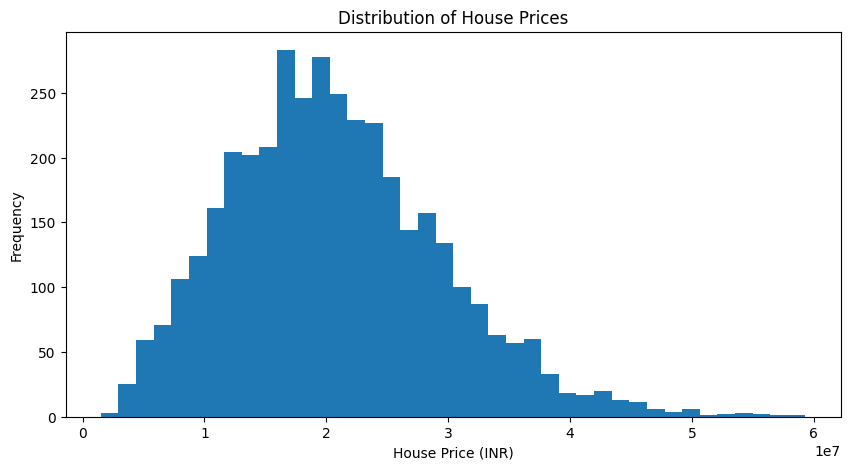

In [218]:
plt.figure(figsize=(10, 5))

plt.hist(df["house_price_inr"], bins=40)

plt.title("Distribution of House Prices")
plt.xlabel("House Price (INR)")
plt.ylabel("Frequency")

plt.show()

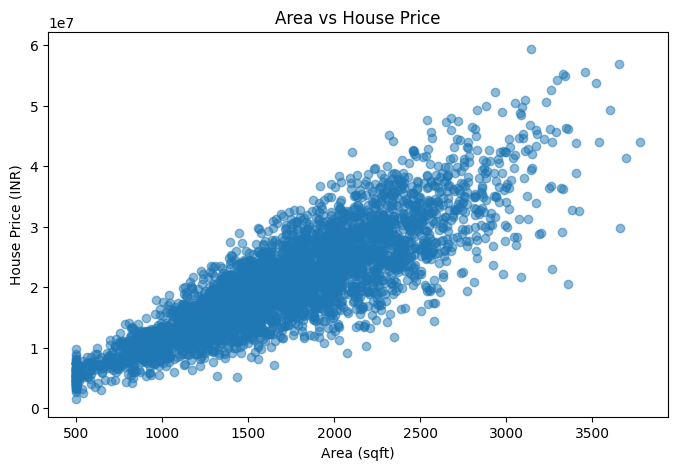

In [219]:
plt.figure(figsize=(8, 5))

plt.scatter(df["area_sqft"], df["house_price_inr"], alpha=0.5)

plt.title("Area vs House Price")
plt.xlabel("Area (sqft)")
plt.ylabel("House Price (INR)")

plt.show()

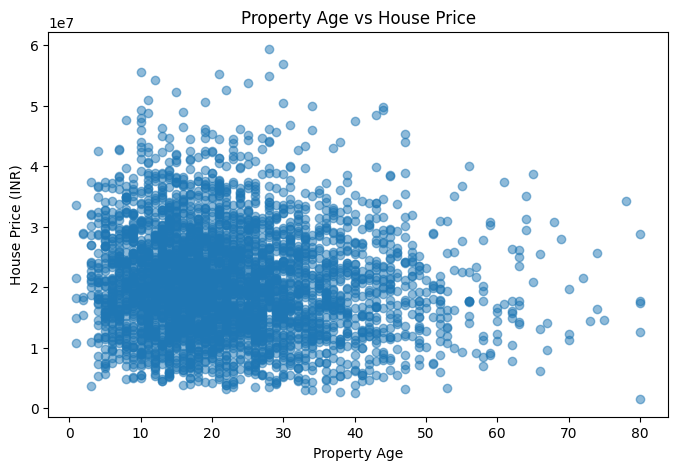

In [220]:
plt.figure(figsize=(8, 5))

plt.scatter(df["property_age"], df["house_price_inr"], alpha=0.5)

plt.title("Property Age vs House Price")
plt.xlabel("Property Age")
plt.ylabel("House Price (INR)")

plt.show()

### Correlation Analysis

Correlation is used to understand the linear relationship between numerical variables.

A positive correlation means that both variables tend to increase together, while a negative correlation means that one variable tends to decrease as the other increases.

In [221]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation["house_price_inr"].sort_values(ascending=False)

house_price_inr     1.000000
area_sqft           0.850342
bedrooms            0.726036
bathrooms           0.610246
location_score      0.429431
property_id        -0.010288
near_school        -0.012357
near_metro         -0.024632
crime_rate_index   -0.052216
property_age       -0.079124
distance_city_km   -0.281461
Name: house_price_inr, dtype: float64

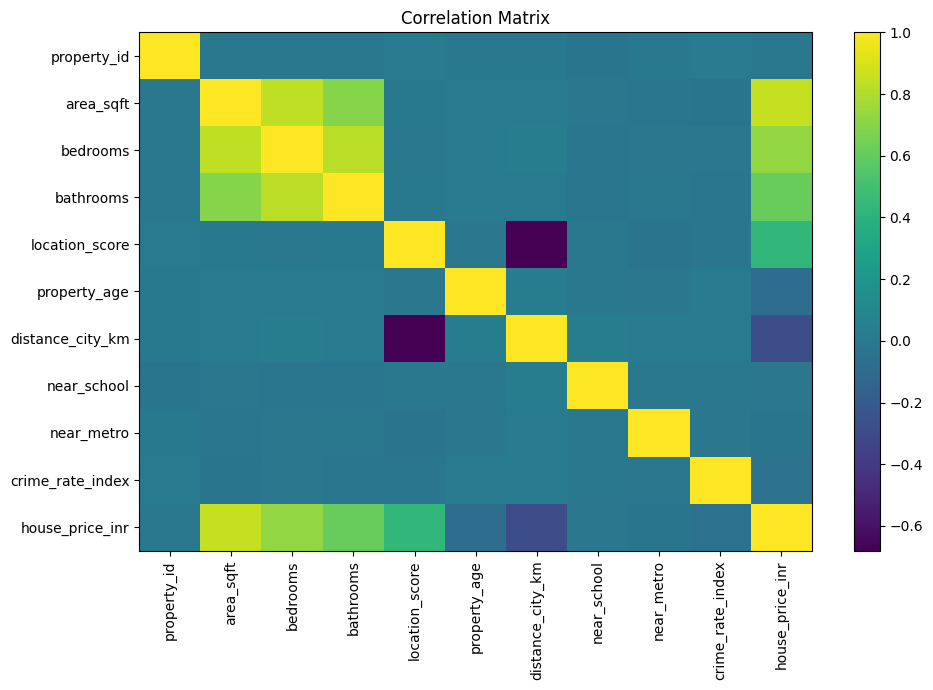

In [222]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## Part D: Data Preparation

The target variable is `house_price_inr`.

The `property_id` column is only an identifier and does not represent a meaningful predictive property, so it is excluded from the machine learning features.

The `sale_date` column is converted into useful time-based features such as:

- Sale Year
- Sale Month
- Sale Quarter

The original date column is then removed.

In [223]:
data = df.copy()

data["sale_date"] = pd.to_datetime(data["sale_date"])

data["sale_year"] = data["sale_date"].dt.year
data["sale_month"] = data["sale_date"].dt.month
data["sale_quarter"] = data["sale_date"].dt.quarter

data = data.drop(columns=["property_id", "sale_date"])

data.head()

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr,sale_year,sale_month,sale_quarter
0,2181,6,4,8.1,21,3.8,0,0,4.84,35154898,2014,1,1
1,2383,5,4,5.3,28,10.9,1,1,2.89,26710893,2019,12,4
2,1047,3,3,5.9,7,27.5,0,1,4.04,11216242,2016,10,4
3,1753,4,3,7.0,27,12.1,0,0,3.28,21984310,2013,3,1
4,1728,4,4,10.0,32,1.4,0,1,3.84,25080429,2013,7,3


## Feature and Target Selection

The target variable is:

`house_price_inr`

All remaining relevant columns are used as input features.

In [224]:
X = data.drop(columns=["house_price_inr"])
y = data["house_price_inr"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (3800, 12)
Target shape: (3800,)

Features:
['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'sale_year', 'sale_month', 'sale_quarter']


## Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% of the data is used for testing.
- `random_state=42` is used to make the split reproducible.

In [225]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3040
Testing samples: 760


## Evaluation Metrics

The regression models will be evaluated using:

### Mean Absolute Error (MAE)
Measures the average absolute difference between actual and predicted values.

### Mean Squared Error (MSE)
Measures the average squared difference between actual and predicted values.

### Root Mean Squared Error (RMSE)
The square root of MSE. It is expressed in the same unit as the target variable.

### R² Score
Measures how much variation in the target variable is explained by the model. A higher R² indicates better explanatory performance.

# Part E: Ridge Regression

Ridge Regression is a regularized linear regression technique that uses L2 regularization.

The regularization term reduces the magnitude of coefficients and helps control overfitting.

The regularization strength is controlled by the parameter α.

In [226]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Alpha:", ridge_grid.best_params_)
print("Best Ridge CV Score:", ridge_grid.best_score_)

Best Ridge Alpha: {'model__alpha': 1}
Best Ridge CV Score: -6227501493563.449


In [227]:
ridge_model = ridge_grid.best_estimator_

ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_test_pred)
ridge_mse = mean_squared_error(y_test, ridge_test_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_test_pred)

print("Ridge Regression Results")
print("-------------------------")
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression Results
-------------------------
MAE : 1944418.717786116
MSE : 6442815379469.38
RMSE: 2538270.154942019
R²  : 0.9199999772257901


# Part F: Lasso Regression

Lasso Regression uses L1 regularization.

Unlike Ridge Regression, Lasso can reduce some feature coefficients exactly to zero. Therefore, it can also perform a form of feature selection.

The regularization strength is controlled using α.

In [228]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000))
])

lasso_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso Alpha:", lasso_grid.best_params_)
print("Best Lasso CV Score:", lasso_grid.best_score_)

Best Lasso Alpha: {'model__alpha': 1000}
Best Lasso CV Score: -6226009125603.761


In [229]:
lasso_model = lasso_grid.best_estimator_

lasso_train_pred = lasso_model.predict(X_train)
lasso_test_pred = lasso_model.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_test_pred)
lasso_mse = mean_squared_error(y_test, lasso_test_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_test_pred)

print("Lasso Regression Results")
print("-------------------------")
print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE:", lasso_rmse)
print("R²  :", lasso_r2)

Lasso Regression Results
-------------------------
MAE : 1944839.7635556802
MSE : 6444541008050.874
RMSE: 2538610.054350781
R²  : 0.9199785502070587


## Ridge vs Lasso Coefficients

The coefficients of Ridge and Lasso are compared to understand the effect of regularization on feature importance.

In [230]:
feature_names = X.columns

ridge_coefficients = ridge_model.named_steps["model"].coef_
lasso_coefficients = lasso_model.named_steps["model"].coef_

coefficient_comparison = pd.DataFrame({
    "Feature": feature_names,
    "Ridge_Coefficient": ridge_coefficients,
    "Lasso_Coefficient": lasso_coefficients
})

coefficient_comparison

,Feature,Ridge_Coefficient,Lasso_Coefficient
0,area_sqft,6.950466e+06,6.956912e+06
1,bedrooms,2.918682e+05,2.861779e+05
2,bathrooms,2.744840e+05,2.738630e+05
3,location_score,3.679429e+06,3.680760e+06
4,property_age,-6.507288e+05,-6.498044e+05
5,distance_city_km,-2.900558e+04,-2.694117e+04
6,near_school,1.564944e+04,1.457935e+04
7,near_metro,5.280544e+04,5.184967e+04
8,crime_rate_index,-1.415789e+05,-1.403754e+05
9,sale_year,3.001371e+05,2.995329e+05


# Part G: Cross-Validation Strategies

Cross-validation is used to estimate model performance across different subsets of the data.

The project requires comparison of:

1. K-Fold Cross-Validation
2. Stratified K-Fold Cross-Validation
3. Leave-One-Out Cross-Validation
4. Time Series Split

## K-Fold Cross-Validation

K-Fold divides the dataset into K approximately equal folds.

For each iteration, one fold is used for validation while the remaining folds are used for training.

This process is repeated until every fold has been used for validation.

In [231]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ridge_kfold_scores = cross_val_score(
    ridge_model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("K-Fold RMSE Scores:")
print(-ridge_kfold_scores)

print("\nMean K-Fold RMSE:", -ridge_kfold_scores.mean())

K-Fold RMSE Scores:
[2538270.15494202 2426343.40769528 2653817.35642691 2404792.03090515
 2472639.85059884]

Mean K-Fold RMSE: 2499172.56011364


## Stratified K-Fold Cross-Validation

Stratified K-Fold is normally designed for classification.

For regression, the continuous target can first be divided into bins. These bins are then used to maintain a similar target distribution across folds.

In [232]:
y_bins = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates="drop"
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = []

for train_idx, val_idx in skf.split(X, y_bins):
    model = ridge_grid.best_estimator_
    
    model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )
    
    predictions = model.predict(X.iloc[val_idx])
    
    rmse = np.sqrt(
        mean_squared_error(
            y.iloc[val_idx],
            predictions
        )
    )
    
    stratified_scores.append(rmse)

print("Stratified K-Fold RMSE Scores:")
print(stratified_scores)

print("\nMean Stratified K-Fold RMSE:",
      np.mean(stratified_scores))

Stratified K-Fold RMSE Scores:
[np.float64(2478815.2211034796), np.float64(2417377.771970629), np.float64(2480583.6913255616), np.float64(2529129.3451240193), np.float64(2590428.529018702)]

Mean Stratified K-Fold RMSE: 2499266.9117084784


## Leave-One-Out Cross-Validation (LOOCV)

LOOCV uses one observation as the validation sample and all remaining observations as training data.

This process is repeated for every observation.

LOOCV can be computationally expensive for large datasets because the model must be trained many times.

In [233]:
# A representative subset is used to demonstrate LOOCV
# because full LOOCV on 3,800 observations is computationally expensive.

sample_size = 300

X_loocv = X.iloc[:sample_size].reset_index(drop=True)
y_loocv = y.iloc[:sample_size].reset_index(drop=True)

loo = LeaveOneOut()

loo_errors = []

for train_idx, val_idx in loo.split(X_loocv):
    
    model = ridge_grid.best_estimator_
    
    model.fit(
        X_loocv.iloc[train_idx],
        y_loocv.iloc[train_idx]
    )
    
    prediction = model.predict(
        X_loocv.iloc[val_idx]
    )[0]
    
    actual = y_loocv.iloc[val_idx].iloc[0]
    
    loo_errors.append(
        (actual - prediction) ** 2
    )

loocv_rmse = np.sqrt(np.mean(loo_errors))

print("LOOCV RMSE on representative sample:", loocv_rmse)

LOOCV RMSE on representative sample: 2540829.425910715


## Time Series Split

Time Series Split preserves the temporal order of observations.

Earlier observations are used for training and later observations are used for validation.

The `sale_date` column is therefore used to create a time-based ordering before applying Time Series Split.

In [234]:
time_data = data.copy()

time_data["original_date"] = df["sale_date"].values

time_data = time_data.sort_values(
    "original_date"
).reset_index(drop=True)

X_time = time_data.drop(
    columns=["house_price_inr", "original_date"]
)

y_time = time_data["house_price_inr"]

tscv = TimeSeriesSplit(n_splits=5)

time_scores = []

for train_idx, val_idx in tscv.split(X_time):
    
    model = ridge_grid.best_estimator_
    
    model.fit(
        X_time.iloc[train_idx],
        y_time.iloc[train_idx]
    )
    
    predictions = model.predict(
        X_time.iloc[val_idx]
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_time.iloc[val_idx],
            predictions
        )
    )
    
    time_scores.append(rmse)

print("Time Series Split RMSE Scores:")
print(time_scores)

print("\nMean Time Series RMSE:",
      np.mean(time_scores))

Time Series Split RMSE Scores:
[np.float64(2626224.863884749), np.float64(2493399.337709005), np.float64(2430217.581399218), np.float64(2431159.859105602), np.float64(2541702.8295823904)]

Mean Time Series RMSE: 2504540.894336193


# Part H: Decision Tree Regression

Decision Tree Regression is a non-linear regression technique.

The tree recursively divides the feature space into smaller regions and predicts a value for each region.

Tree complexity can be controlled using parameters such as:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

In [235]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_params = {
    "max_depth": [3, 5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

dt_grid = GridSearchCV(
    dt_model,
    dt_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

Best Decision Tree Parameters:
{'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [236]:
dt_best = dt_grid.best_estimator_

dt_train_pred = dt_best.predict(X_train)
dt_test_pred = dt_best.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_test_pred)
dt_mse = mean_squared_error(y_test, dt_test_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_test_pred)

print("Decision Tree Results")
print("---------------------")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R²  :", dt_r2)

Decision Tree Results
---------------------
MAE : 2065624.3112442237
MSE : 7909988698490.216
RMSE: 2812470.2129071904
R²  : 0.9017821808088071


# Part I: Random Forest Regression

Random Forest Regression is an ensemble learning technique.

It combines multiple decision trees and averages their predictions. This generally provides better stability than using a single decision tree.

rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

In [237]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)

rf_best = rf_grid.best_estimator_

rf_train_pred = rf_best.predict(X_train)
rf_test_pred = rf_best.predict(X_test)

print("Predictions generated successfully.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Predictions generated successfully.


# Part J: Support Vector Regression

Support Vector Regression (SVR) is a supervised learning algorithm that can model both linear and non-linear relationships.

The important SVR hyperparameters include:

- `C` – controls the penalty for errors.
- `gamma` – controls the influence of individual training examples for non-linear kernels.
- `epsilon` – defines the epsilon-insensitive region.
- `kernel` – determines the type of transformation.

## SVR with Linear Kernel

In [238]:
svr_linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="linear"))
])

svr_linear_params = {
    "svr__C": [0.1, 1, 10, 100],
    "svr__epsilon": [0.01, 0.1, 0.5]
}

svr_linear_grid = GridSearchCV(
    svr_linear_pipeline,
    svr_linear_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

svr_linear_grid.fit(X_train, y_train)

print("Best Linear SVR Parameters:")
print(svr_linear_grid.best_params_)

Best Linear SVR Parameters:
{'svr__C': 100, 'svr__epsilon': 0.5}


## SVR with RBF Kernel

The RBF kernel is useful for capturing non-linear relationships between input variables and house prices.

In [239]:
svr_rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

svr_rbf_params = {
    "svr__C": [1, 10, 100],
    "svr__gamma": ["scale", 0.01, 0.1],
    "svr__epsilon": [0.01, 0.1, 0.5]
}

svr_rbf_grid = GridSearchCV(
    svr_rbf_pipeline,
    svr_rbf_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

svr_rbf_grid.fit(X_train, y_train)

print("Best RBF SVR Parameters:")
print(svr_rbf_grid.best_params_)

Best RBF SVR Parameters:
{'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}


In [240]:
svr_linear_best = svr_linear_grid.best_estimator_
svr_rbf_best = svr_rbf_grid.best_estimator_

svr_linear_pred = svr_linear_best.predict(X_test)
svr_rbf_pred = svr_rbf_best.predict(X_test)

svr_linear_rmse = np.sqrt(
    mean_squared_error(y_test, svr_linear_pred)
)

svr_linear_mae = mean_absolute_error(
    y_test,
    svr_linear_pred
)

svr_linear_r2 = r2_score(
    y_test,
    svr_linear_pred
)

svr_rbf_rmse = np.sqrt(
    mean_squared_error(y_test, svr_rbf_pred)
)

svr_rbf_mae = mean_absolute_error(
    y_test,
    svr_rbf_pred
)

svr_rbf_r2 = r2_score(
    y_test,
    svr_rbf_pred
)

print("Linear SVR")
print("MAE :", svr_linear_mae)
print("RMSE:", svr_linear_rmse)
print("R²  :", svr_linear_r2)

print("\nRBF SVR")
print("MAE :", svr_rbf_mae)
print("RMSE:", svr_rbf_rmse)
print("R²  :", svr_rbf_r2)

Linear SVR
MAE : 6620438.304480794
RMSE: 8521394.254877854
R²  : 0.09835466091319589

RBF SVR
MAE : 6986006.987844421
RMSE: 8977582.42264727
R²  : -0.0007675756957237212


# Part K: Model Comparison

All implemented models are compared using common regression metrics.

Models included:

- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Random Forest Regression
- Linear SVR
- RBF SVR

In [241]:
rf_mae = mean_absolute_error(y_test, rf_test_pred)
rf_mse = mean_squared_error(y_test, rf_test_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest Evaluation")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Evaluation
MAE : 1747161.0855295307
MSE : 5707392731019.405
RMSE: 2389015.012723739
R2  : 0.9291316727904569


In [242]:
results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Linear SVR",
        "RBF SVR"
    ],

    "MAE": [
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae,
        svr_linear_mae,
        svr_rbf_mae
    ],

    "MSE": [
        ridge_mse,
        lasso_mse,
        dt_mse,
        rf_mse,
        mean_squared_error(y_test, svr_linear_pred),
        mean_squared_error(y_test, svr_rbf_pred)
    ],

    "RMSE": [
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse,
        svr_linear_rmse,
        svr_rbf_rmse
    ],

    "R2": [
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2,
        svr_linear_r2,
        svr_rbf_r2
    ]
})

results = results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

results

,Model,MAE,MSE,RMSE,R2
0,Random Forest,1.747161e+06,5.707393e+12,2.389015e+06,0.929132
1,Ridge Regression,1.944419e+06,6.442815e+12,2.538270e+06,0.920000
2,Lasso Regression,1.944840e+06,6.444541e+12,2.538610e+06,0.919979
3,Decision Tree,2.065624e+06,7.909989e+12,2.812470e+06,0.901782
4,Linear SVR,6.620438e+06,7.261416e+13,8.521394e+06,0.098355
5,RBF SVR,6.986007e+06,8.059699e+13,8.977582e+06,-0.000768


## Model Performance Visualization

RMSE is compared across the different regression models.

Lower RMSE indicates smaller prediction errors on the test dataset.

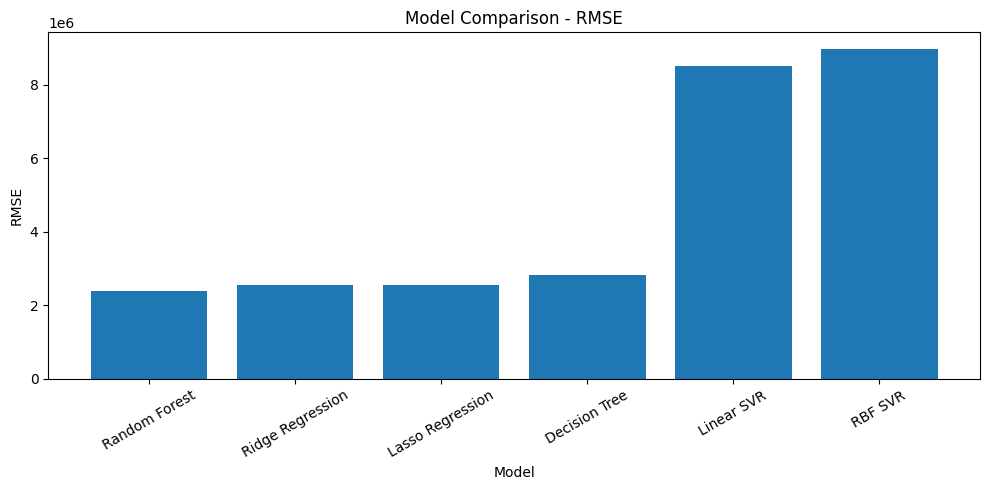

In [243]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

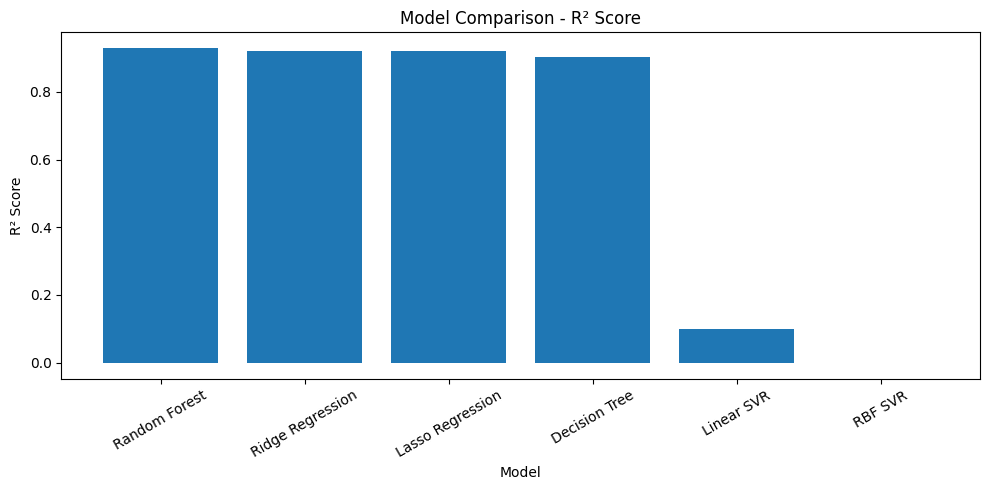

In [244]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Part L: Overfitting and Underfitting Analysis

Overfitting occurs when a model performs very well on training data but performs significantly worse on unseen data.

Underfitting occurs when a model performs poorly on both training and testing data.

The difference between training and testing performance is therefore examined for the major models.

In [245]:
overfitting_results = pd.DataFrame({
    "Model": [
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Train_R2": [
        r2_score(y_train, ridge_train_pred),
        r2_score(y_train, lasso_model.predict(X_train)),
        r2_score(y_train, dt_train_pred),
        r2_score(y_train, rf_train_pred)
    ],
    
    "Test_R2": [
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2
    ]
})

overfitting_results

,Model,Train_R2,Test_R2
0,Ridge,0.917420,0.920000
1,Lasso,0.917419,0.919979
2,Decision Tree,0.947247,0.901782
3,Random Forest,0.976690,0.929132


## Feature Importance

Random Forest provides feature importance values that indicate the relative contribution of each feature to the model.

In [246]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_best.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,area_sqft,0.753287
3,location_score,0.207630
4,property_age,0.010247
5,distance_city_km,0.007092
8,crime_rate_index,0.006465
9,sale_year,0.004675
10,sale_month,0.003313
1,bedrooms,0.002496
2,bathrooms,0.002401
7,near_metro,0.000962


In [247]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_best.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,area_sqft,0.753287
3,location_score,0.207630
4,property_age,0.010247
5,distance_city_km,0.007092
8,crime_rate_index,0.006465
9,sale_year,0.004675
10,sale_month,0.003313
1,bedrooms,0.002496
2,bathrooms,0.002401
7,near_metro,0.000962


# Part M: Actual vs Predicted Values

The actual and predicted house prices are compared for the best-performing model.

A good regression model should produce predictions that are close to the actual values.

In [248]:
comparison = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": rf_test_pred
})

comparison.head(20)

,Actual_Price,Predicted_Price
0,11785035,1.203624e+07
1,22027660,1.987065e+07
2,25934680,2.252479e+07
3,23575933,2.227419e+07
4,37038561,3.193335e+07
5,6256815,7.619402e+06
6,29760172,2.991705e+07
7,26583923,2.869503e+07
8,47238485,3.726471e+07
9,8463759,6.877309e+06


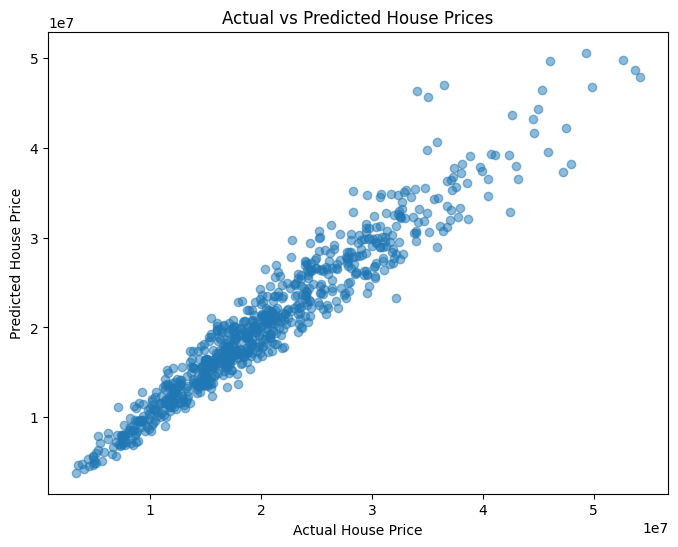

In [249]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_test_pred,
    alpha=0.5
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [250]:
best_model_row = results.sort_values(
    by="RMSE",
    ascending=True
).iloc[0]

print("Best Performing Model:")
print(best_model_row["Model"])

print("\nPerformance:")
print("MAE :", best_model_row["MAE"])
print("MSE :", best_model_row["MSE"])
print("RMSE:", best_model_row["RMSE"])
print("R²  :", best_model_row["R2"])

Best Performing Model:
Random Forest

Performance:
MAE : 1747161.0855295307
MSE : 5707392731019.405
RMSE: 2389015.012723739
R²  : 0.9291316727904569


# Part O: Final Analysis and Business Interpretation

## Regularization

Ridge and Lasso regression introduce regularization to reduce the risk of overfitting. Ridge shrinks coefficients toward zero, while Lasso can reduce some coefficients completely to zero.

## Cross-Validation

Cross-validation provides a more reliable estimate of model performance by evaluating models across multiple training and validation splits. Different strategies can produce different performance estimates because they divide the data differently.

## Linear vs Non-Linear Models

Ridge, Lasso, and linear SVR model relationships primarily through linear functions. Decision Trees, Random Forests, and RBF SVR can capture more complex non-linear relationships.

## Tree-Based Models

Decision Tree Regression can model non-linear relationships but may overfit when the tree becomes too complex. Random Forest reduces this problem by combining predictions from multiple trees.

## Business Interpretation

Accurate house price prediction can help a real estate company estimate property values, support pricing decisions, identify important property characteristics, and improve consistency in automated predictions.

The final model should be selected based on validation and test performance rather than training performance alone.

# Final Conclusion

This project implemented a complete robust regression pipeline for house price prediction.

The workflow included:

1. Dataset understanding and preprocessing.
2. Exploratory Data Analysis.
3. Feature and target selection.
4. Train-test splitting.
5. Ridge Regression.
6. Lasso Regression.
7. K-Fold Cross-Validation.
8. Stratified K-Fold Cross-Validation using target binning.
9. Leave-One-Out Cross-Validation.
10. Time Series Split.
11. Decision Tree Regression.
12. Random Forest Regression.
13. Linear Support Vector Regression.
14. RBF Support Vector Regression.
15. Hyperparameter tuning.
16. Model evaluation using MAE, MSE, RMSE, and R².
17. Overfitting and underfitting analysis.
18. Feature importance analysis.
19. Actual vs predicted visualization.
20. Final model comparison.

The final model is selected based on its performance on unseen test data and its ability to generalize effectively.